<a href="https://colab.research.google.com/github/RabinPhuyal/Traffic-Sign-Classification-With-Pytorch/blob/main/Traffic_Sign_Classification_With_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Traffic Sign Classification with PyTorch

A computer vision project for classifying traffic signs using a Convolutional Neural Network (CNN) and the GTSRB dataset.

In [7]:
#Import necesarry libraries
#PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader

#Torchvision
from torchvision import datasets
from torchvision import transforms

#Data analysis and visualization
import numpy as np
import matplotlib.pyplot as plt

#Randomness
import random

#Checkh PyTorch Version
print(f"PyTorch version: {torch.__version__}")

#Check device
device="cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

PyTorch version: 2.11.0+cu130
Using device: cuda


## 1.Download and Load the GTSRB Dataset

In [8]:
train_data = datasets.GTSRB(
    root="data",
    split="train",
    download=True
)

test_data = datasets.GTSRB(
    root="data",
    split="test",
    download=True
)

100%|██████████| 187M/187M [00:20<00:00, 9.07MB/s]
100%|██████████| 89.0M/89.0M [00:11<00:00, 7.73MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 180kB/s]


In [9]:
#Check the dataset

print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")

Training samples: 26640
Testing samples: 12630


In [10]:
'''GTSRB has 43 classes, numbered 0 through 42 and dataitself gives us the
numerical labels, but not a convenient .classes list '''

class_names = [
    "Speed limit 20 km/h",
    "Speed limit 30 km/h",
    "Speed limit 50 km/h",
    "Speed limit 60 km/h",
    "Speed limit 70 km/h",
    "Speed limit 80 km/h",
    "End of speed limit 80 km/h",
    "Speed limit 100 km/h",
    "Speed limit 120 km/h",
    "No passing",
    "No passing for vehicles over 3.5 metric tons",
    "Right-of-way at the next intersection",
    "Priority road",
    "Yield",
    "Stop",
    "No vehicles",
    "Vehicles over 3.5 metric tons prohibited",
    "No entry",
    "General caution",
    "Dangerous curve to the left",
    "Dangerous curve to the right",
    "Double curve",
    "Bumpy road",
    "Slippery road",
    "Road narrows on the right",
    "Road work",
    "Traffic signals",
    "Pedestrians",
    "Children crossing",
    "Bicycles crossing",
    "Beware of ice/snow",
    "Wild animals crossing",
    "End of all speed and passing limits",
    "Turn right ahead",
    "Turn left ahead",
    "Ahead only",
    "Go straight or right",
    "Go straight or left",
    "Keep right",
    "Keep left",
    "Roundabout mandatory",
    "End of no passing",
    "End of no passing by vehicles over 3.5 metric tons"
]

print(f"Number of classes: {len(class_names)}")

Number of classes: 43


In [11]:
#Inspect one image

image,label = train_data[0]

print(f"Image type: {type(image)}")
print(f"Image size: {image.size}")
print(f"Label: {class_names[label]}")

Image type: <class 'PIL.Image.Image'>
Image size: (29, 30)
Label: Speed limit 20 km/h


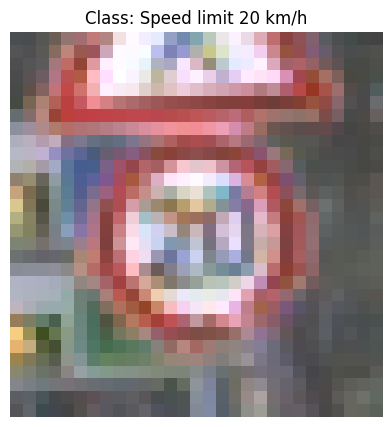

In [12]:
#Visualize our first image

plt.figure(figsize=(5,5))

plt.imshow(image)

plt.title(f"Class: {class_names[label]}")
plt.axis("off")

plt.show()

## 2. Explore the Dataset

In [13]:
random_index = random.randint(0,len(train_data)-1)

image,label = train_data[random_index]

print(f"Random index: {random_index}")
print(f"Image size: {image.size}")
print(f"Label: {label}")
print(f"Class: {class_names[label]}")

Random index: 14543
Image size: (90, 68)
Label: 13
Class: Yield


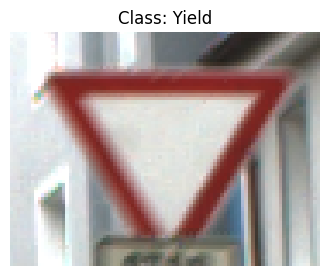

In [14]:
#Display the image
plt.figure(figsize=(4,4))

plt.imshow(image)

plt.title(f"Class: {class_names[label]}")
plt.axis("off")

plt.show()

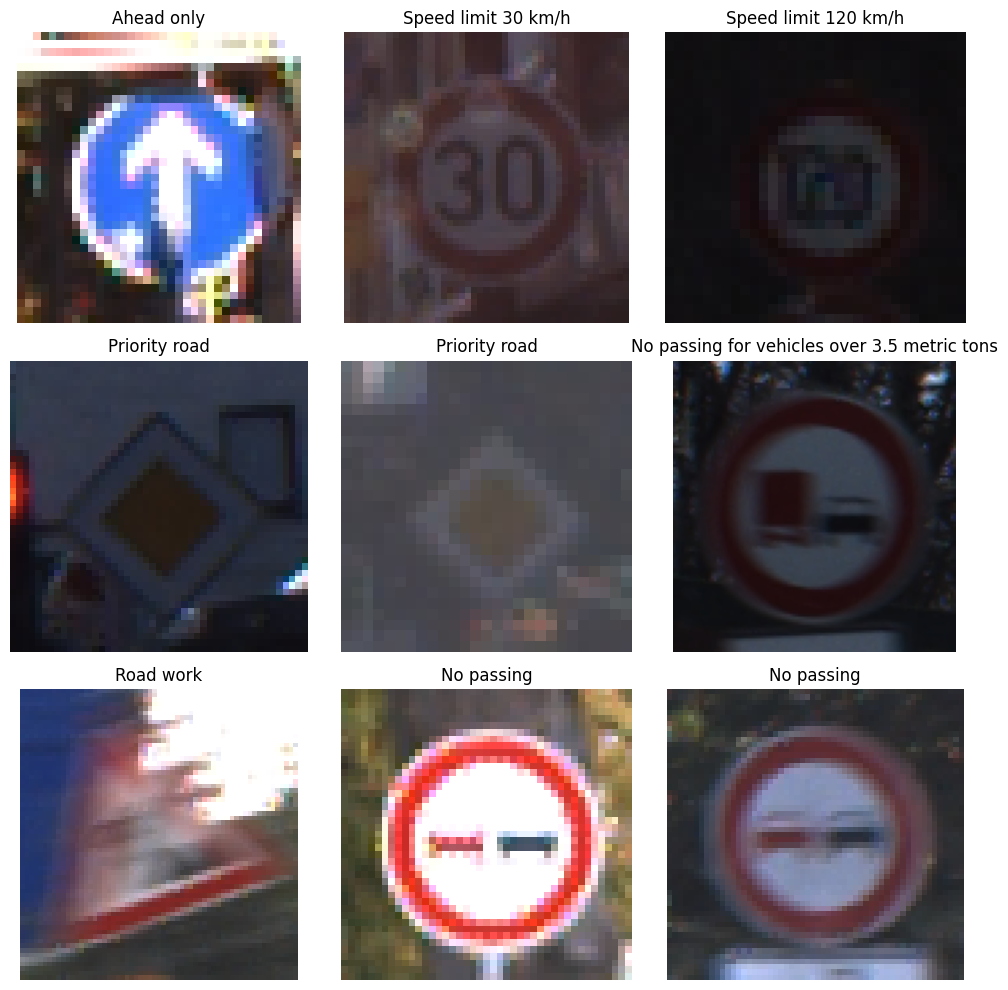

In [15]:
#Display 9 random images

plt.figure(figsize=(10,10))

for i in range(9):
  random_index= random.randint(0,len(train_data)-1)

  image, label = train_data[random_index]

  plt.subplot(3,3,i+1)
  plt.imshow(image)
  plt.title(class_names[label])
  plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
#Check the image dimensions
image_sizes = []
for image,label in train_data:
  image_sizes.append(image.size)

print(f"Number of Images: {len(image_sizes)}")
print(f"First 10 Image sizes: {image_sizes[:10]}")

Number of Images: 26640
First 10 Image sizes: [(29, 30), (30, 30), (30, 30), (31, 31), (30, 32), (31, 31), (33, 34), (34, 35), (33, 34), (36, 36)]


In [17]:
unique_sizes = set(image_sizes)

print(f"Number of unique image sizes: {len(unique_sizes)}")
print(f"Some unique sizes: {list(unique_sizes)[:20]}")

Number of unique image sizes: 2489
Some unique sizes: [(107, 95), (67, 59), (167, 146), (59, 55), (118, 104), (70, 64), (170, 151), (29, 32), (48, 45), (148, 132), (40, 41), (100, 92), (119, 105), (92, 88), (65, 134), (151, 137), (111, 101), (63, 61), (61, 100), (41, 42)]


## 3. Image Transformations

In [18]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

In [19]:
train_data = datasets.GTSRB(
    root="data",
    split="train",
    transform=train_transform,
    download=True
)

test_data = datasets.GTSRB(
    root="data",
    split="test",
    transform=test_transform,
    download=True
)

In [20]:
#DataLoader for calculating dataset statistics
BATCH_SIZE=32
stats_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle = False
)

#Initialize mean and standard devation
mean = torch.zeros(3)
std = torch.zeros(3)

#Calculate statistics for each RGB channel
for images,_ in stats_loader:
  mean +=images.mean(dim=[0,2,3])
  std+= images.std(dim=[0,2,3])

#Average across batches
mean /= len(stats_loader)
std /= len(stats_loader)

print("Mean: ", mean)
print("Std: ", std)

Mean:  tensor([0.3416, 0.3125, 0.3215])
Std:  tensor([0.2026, 0.1995, 0.2089])


In [21]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [22]:
#Inspecting image
image,label = train_data[0]

print(f"Image type: {type(image)}")
print(f"Image size: {image.shape}")
print(f"Label: {label}")
print(f"Class Name: {class_names[label]}")

Image type: <class 'torch.Tensor'>
Image size: torch.Size([3, 64, 64])
Label: 0
Class Name: Speed limit 20 km/h


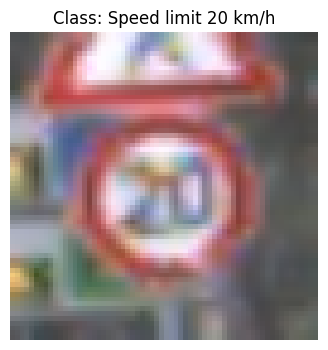

In [23]:
#Visualize the transformed image
plt.figure(figsize=(4,4))

plt.imshow(image.permute(1,2,0))

plt.title(f"Class: {class_names[label]}")
plt.axis("off")

plt.show()

In [24]:
#Creating the validation set
from torch.utils.data import random_split

#Set a seed so out split in reproducible
torch.manual_seed(42)

#Calculate split sizes
train_size = int(0.8*len(train_data))
val_size = len(train_data) - train_size

print(f"Training size: {train_size}")
print(f"Validation size: {val_size}")

Training size: 21312
Validation size: 5328


In [25]:
train_dataset, val_dataset = random_split(
    train_data,
    [train_size, val_size]
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 21312
Validation samples: 5328


In [26]:
# Create our DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle= True
)
val_loader = DataLoader(
    val_dataset,
    batch_size= BATCH_SIZE,
    shuffle=False
)
test_loader = DataLoader(
    test_data,
    batch_size= BATCH_SIZE,
    shuffle= False
)

In [27]:
#Inspect one batch
train_images, train_labels = next(iter(train_loader))

print(f"Images shape: {train_images.shape}")
print(f"Labels shape: {train_labels.shape}")

Images shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])


In [28]:
print(f"First 10 labels: {train_labels[:10]}")

First 10 labels: tensor([12, 12,  8, 38,  7, 17, 12,  8,  3,  4])


In [29]:
for label in train_labels[:10]:
  print(f"{label.item()} -> {class_names[label.item()]}")

12 -> Priority road
12 -> Priority road
8 -> Speed limit 120 km/h
38 -> Keep right
7 -> Speed limit 100 km/h
17 -> No entry
12 -> Priority road
8 -> Speed limit 120 km/h
3 -> Speed limit 60 km/h
4 -> Speed limit 70 km/h


In [30]:
#DataLoader for calculating dataset statistics
stats_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle = False
)

#Initialize mean and standard devation
mean = torch.zeros(3)
std = torch.zeros(3)

#Calculate statistics for each RGB channel
for images,_ in stats_loader:
  mean +=images.mean(dim=[0,2,3])
  std+= images.std(dim=[0,2,3])

#Average across batches
mean /= len(stats_loader)
std /= len(stats_loader)

print("Mean: ", mean)
print("Std: ", std)

Mean:  tensor([0.3416, 0.3125, 0.3215])
Std:  tensor([0.2026, 0.1995, 0.2089])


In [31]:
train_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean,std=std)
])
test_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [32]:
train_data = datasets.GTSRB(
    root="data",
    split="train",
    transform=train_transform,
    download=True
)

test_data = datasets.GTSRB(
    root="data",
    split="test",
    transform=test_transform,
    download=True
)

In [33]:
torch.manual_seed(42)

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

train_dataset, val_dataset = random_split(
    train_data,
    [train_size, val_size]
)

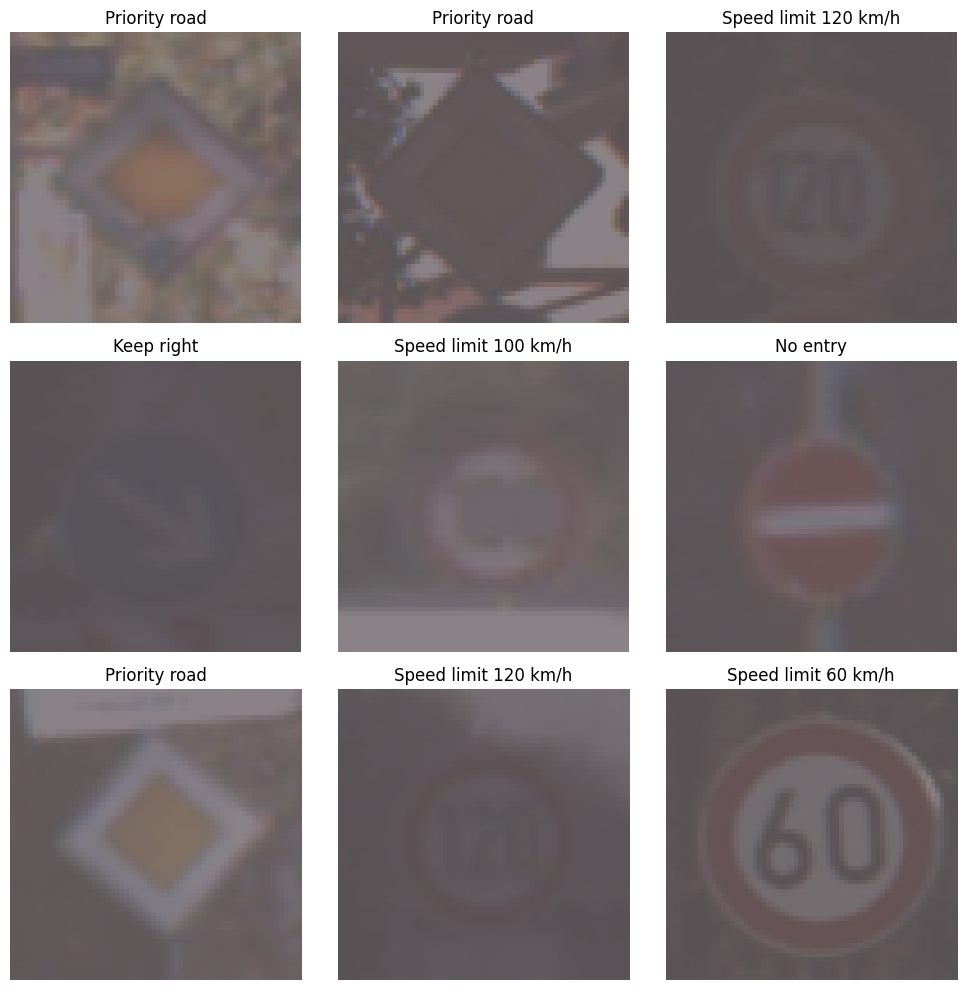

In [34]:
#Visualize a batch

#Get one batch
images, labels= next(iter(train_loader))

#Denormalize
images = images*std[:, None, None] + mean[:,None,None]

#Plot 9 images
plt.figure(figsize=(10,10))

for i in range(9):
  plt.subplot(3,3,i+1)

  image = images[i]

  #Convert CHW -> HWC for matplotlib
  plt.imshow(image.permute(1,2,0).clamp(0,1))

  plt.title(class_names[labels[i].item()])
  plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
#Create the CNN model

class TrafficSignCNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels = 3,
                  out_channels = 32,
                  kernel_size= 3,
                  padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels =32,
                  out_channels = 64,
                  kernel_size=3,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.block_conv_3 = nn.Sequential(
        nn.Conv2d(in_channels=64,
                  out_channels=128,
                  kernel_size=3,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(
            in_features = 128 * 8 * 8,
            out_features = 43
        )
    )

  def forward(self,x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.block_conv_3(x)
    x = self.classifier(x)

    return x

In [36]:
model = TrafficSignCNN()

dummy_image = torch.randn(1,3,64,64)

output = model(dummy_image)

print("Input shape: ",dummy_image.shape)
print("Output shape: ",output.shape)

Input shape:  torch.Size([1, 3, 64, 64])
Output shape:  torch.Size([1, 43])


In [37]:
images, labels = next(iter(train_loader))

output = model(images)

print("Images: ",images.shape)
print("Output: ",output.shape)

Images:  torch.Size([32, 3, 64, 64])
Output:  torch.Size([32, 43])


In [38]:
#Move the model to the GPU
model = TrafficSignCNN().to(device)

In [39]:
#Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    params = model.parameters(),
    lr = 0.001
)

In [40]:
#Creating training step

def train_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device: torch.device = device):
  model.train()

  train_loss = 0
  train_acc = 0

  for images,labels in data_loader:

    #Move data to GPU
    images = images.to(device)
    labels = labels.to(device)

    #1. Forward pass
    predictions = model(images)

    #2. Calculate loss
    loss = loss_fn(predictions,labels)
    predicted_classes = predictions.argmax(dim=1)

    # Calculate accuracy
    train_acc +=(
        (predicted_classes == labels).float().mean().item()
    )

    #3. Zero gradients
    optimizer.zero_grad()

    #4. Loss Backwards
    loss.backward()

    #5. Update weights
    optimizer.step()

    train_loss += loss.item()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)

  return train_loss, train_acc

In [41]:
#Testing the function
train_loss, train_acc = train_step(
    model=model,
    data_loader = train_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device
)

print(f"Training loss: {train_loss:.4f}")
print(f"Training accuracy: {train_acc:.4f}")

Training loss: 1.2551
Training accuracy: 0.6549


In [42]:
#Create val_step()
def val_step(model,
             data_loader,
             loss_fn,
             device):
  model.eval()

  val_loss = 0
  val_acc = 0

  with torch.inference_mode():
    for images,labels in data_loader:

      #Move data to device
      images = images.to(device)
      labels = labels.to(device)

      #Forward pass
      predictions = model(images)

      #Calculate loss
      loss = loss_fn(predictions, labels)

      val_loss += loss.item()

      #Calculate accuracy
      predicted_classes = predictions.argmax(dim=1)

      val_acc += ((predicted_classes==labels).float().mean().item())

  #Average across batches
  val_loss /=len(data_loader)
  val_acc /= len(data_loader)
  return val_loss,val_acc

In [43]:
val_loss, val_acc = val_step(
    model=model,
    data_loader=val_loader,
    loss_fn=loss_fn,
    device=device
)

print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")

Validation loss: 0.2388
Validation accuracy: 0.9298
